In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import torch
import l4casadi as l4c

In [2]:
hidden_size = 64
hidden_layers_dim = 8

# Simple NN
class MultiLayerPerceptron(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.input_layer = torch.nn.Linear(input_dim, hidden_size)

        hidden_layers = []
        for i in range(hidden_layers_dim):
            hidden_layers.append(torch.nn.Linear(hidden_size, hidden_size))

        self.hidden_layer = torch.nn.ModuleList(hidden_layers)
        self.out_layer = torch.nn.Linear(hidden_size, 1)

    def forward(self, x):

        x = self.input_layer(x)
        for layer in self.hidden_layer:
            x = torch.tanh(layer(x))
        x = self.out_layer(x)
        return x


--- Pre-calculating predictions for global normalization ---
Successfully loaded model for pre-calculation: best_model_epoch_9.pth
Successfully loaded model for pre-calculation: best_model_epoch_9.pth
Successfully loaded model for pre-calculation: best_model_epoch_10.pth
Successfully loaded model for pre-calculation: best_model_epoch_10.pth
Global min/max for heatmap scale: 0.4786 / 0.7623
--- Finished pre-calculation ---


/tmp/ipykernel_346417/3840708909.py:163: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.ax.set_yticklabels(ticklabs, fontsize=15)
/tmp/ipykernel_346417/3840708909.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.8, 0.96])


Figure successfully saved as nn_surrogate_orientation_heatmaps.eps


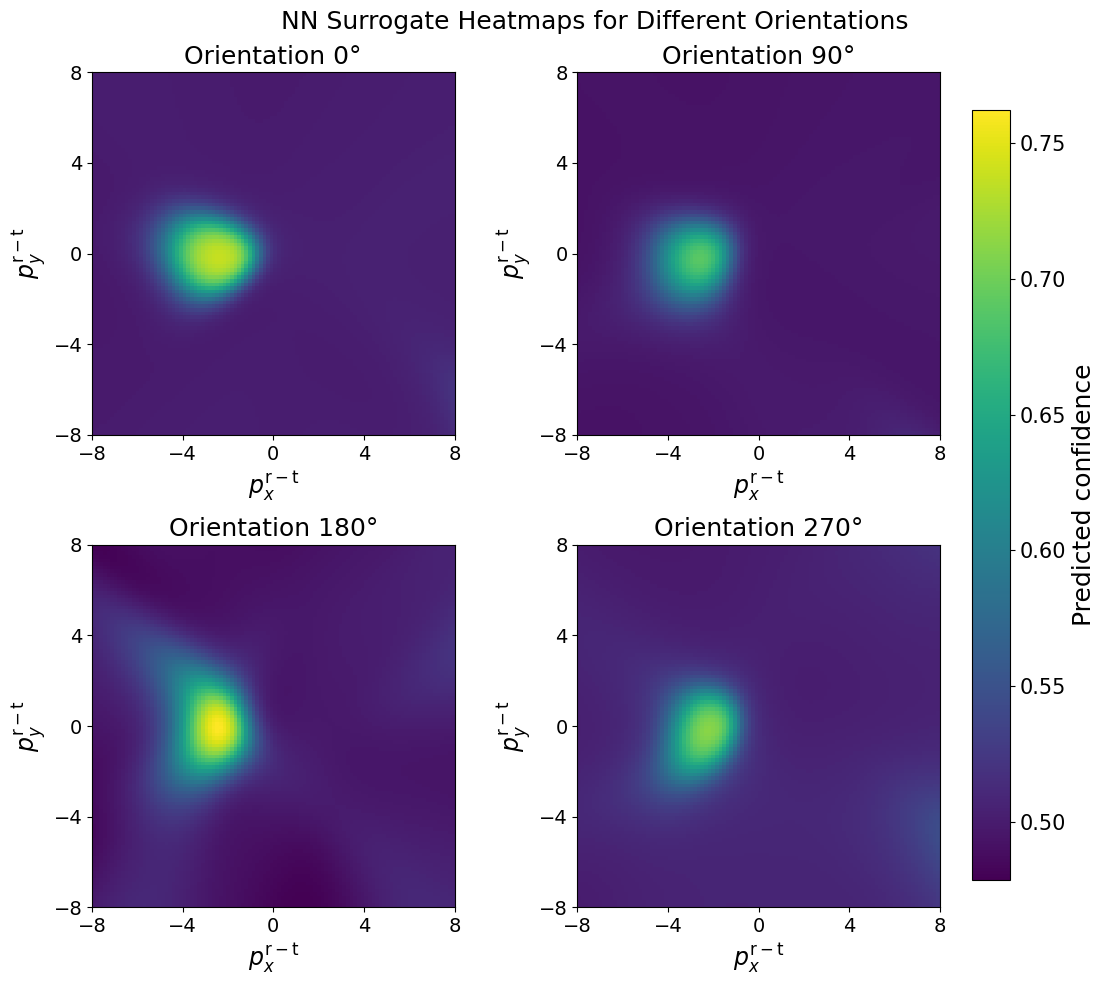

Script finished.


In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

import l4casadi as l4c

SCRIPT_DIR = os.path.abspath('')

RELATIVE_MODEL_PATHS = [
    "datasets/varying_orientation_datasets/00-degrees/20250423_114142/best_model_epoch_9.pth",
    "datasets/varying_orientation_datasets/90-degrees/20250423_114841/best_model_epoch_9.pth",
    "datasets/varying_orientation_datasets/180-degrees/20250423_115209/best_model_epoch_10.pth",
    "datasets/varying_orientation_datasets/270-degrees/20250423_120415/best_model_epoch_10.pth"
]

MODEL_PATHS = [os.path.join(SCRIPT_DIR, rel_path) for rel_path in RELATIVE_MODEL_PATHS]

# --- Plotting and Model Parameters ---
X_MIN, X_MAX = -8, 8
Y_MIN, Y_MAX = -8, 8
N_POINTS = 100
FIXED_YAW_RAD = 0.0

MODEL_INPUT_DIM = 4
MODEL_HIDDEN_DIM = 64
MODEL_OUTPUT_DIM = 1
MODEL_NUM_LAYERS = 8
MODEL_ACTIVATION = 'Tanh'

FIGURE_SIZE = (12, 10)

OUTPUT_FILENAME = 'nn_surrogate_orientation_heatmaps.eps'

FIGURE_TITLES = [
    "Orientation 0°",
    "Orientation 90°",
    "Orientation 180°",
    "Orientation 270°"
]
SUBPLOT_ERROR_TITLE_SUFFIX_NOT_FOUND = "(Model Not Found)"
SUBPLOT_ERROR_TITLE_SUFFIX_LOAD_ERROR = "(Model Load Error)"
SUBPLOT_ERROR_MESSAGE_NOT_FOUND = 'Model file missing'
SUBPLOT_ERROR_MESSAGE_LOAD_ERROR = 'Error loading model'
X_AXIS_LABEL_TEXT = r'$x_1$'
Y_AXIS_LABEL_TEXT = r'$x_2$'
COLORBAR_LABEL_TEXT = 'Estimated Confidence'



x_coordinates = np.linspace(X_MIN, X_MAX, N_POINTS)
y_coordinates = np.linspace(Y_MIN, Y_MAX, N_POINTS)

X_grid_mesh, Y_grid_mesh = np.meshgrid(x_coordinates, y_coordinates)
num_grid_points = X_grid_mesh.size

sin_agent_yaw = np.sin(FIXED_YAW_RAD)
cos_agent_yaw = np.cos(FIXED_YAW_RAD)

X_input_for_model = np.column_stack([
    X_grid_mesh.ravel(),
    Y_grid_mesh.ravel(),
    np.full(num_grid_points, sin_agent_yaw),
    np.full(num_grid_points, cos_agent_yaw)
])

inputs_tensor_global = torch.tensor(X_input_for_model, dtype=torch.float32)

all_heatmap_data = {}
global_min_pred_val = float('inf')
global_max_pred_val = float('-inf')
any_model_processed_successfully = False

print("--- Pre-calculating predictions for global normalization ---")
for model_path in MODEL_PATHS:
    try:
        model = l4c.naive.MultiLayerPerceptron(
            MODEL_INPUT_DIM,
            MODEL_HIDDEN_DIM,
            MODEL_OUTPUT_DIM,
            MODEL_NUM_LAYERS,
            MODEL_ACTIVATION
        )
        state_dict = torch.load(model_path, map_location=torch.device('cpu'))
        model.load_state_dict(state_dict)
        model.eval()
        print(f"Successfully loaded model for pre-calculation: {os.path.basename(model_path)}")

        with torch.no_grad():
            predictions_tensor = model(inputs_tensor_global)
            z_predictions_flat = predictions_tensor.numpy().ravel()

        current_Z_heatmap_data = z_predictions_flat.reshape(N_POINTS, N_POINTS) + 0.5
        all_heatmap_data[model_path] = current_Z_heatmap_data

        global_min_pred_val = min(global_min_pred_val, current_Z_heatmap_data.min())
        global_max_pred_val = max(global_max_pred_val, current_Z_heatmap_data.max())
        any_model_processed_successfully = True

    except FileNotFoundError:
        print(f"ERROR: Model file not found at {model_path} during pre-calculation. Plot will show error.")
        all_heatmap_data[model_path] = None
    except Exception as e:
        print(f"ERROR: Could not load model {model_path} during pre-calculation: {e}. Plot will show error.")
        all_heatmap_data[model_path] = None

if not any_model_processed_successfully:
    print("WARNING: No models were successfully processed. Heatmap normalization might be inaccurate (using defaults 0-1).")

    global_min_pred_val = 0.0
    global_max_pred_val = 1.0
else:
    print(f"Global min/max for heatmap scale: {global_min_pred_val:.4f} / {global_max_pred_val:.4f}")
print("--- Finished pre-calculation ---")


fig, axes = plt.subplots(2, 2, figsize=FIGURE_SIZE)
fig.subplots_adjust(right=0.85)
legend_handles_for_figure = [] 
latest_heatmap_object_for_colorbar = None 

for idx, (model_path, title) in enumerate(zip(MODEL_PATHS, FIGURE_TITLES)): 
    ax_row = idx // 2
    ax_col = idx % 2
    current_ax = axes[ax_row, ax_col]

    Z_heatmap_data_for_plot = all_heatmap_data.get(model_path) 

    heatmap_image = current_ax.imshow(
        Z_heatmap_data_for_plot,
        origin='lower',
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        aspect='equal',
        cmap='viridis',
        vmin=global_min_pred_val, 
        vmax=global_max_pred_val  
    )
    latest_heatmap_object_for_colorbar = heatmap_image 
  
    from matplotlib.ticker import MultipleLocator
    current_ax.tick_params(axis='both', labelsize=14)
    current_ax.xaxis.set_major_locator(MultipleLocator(4))
    current_ax.yaxis.set_major_locator(MultipleLocator(4))
    current_ax.set_xlabel(r'$p^{\mathrm{r-t}}_x$', fontsize=17)
    current_ax.set_ylabel(r'$p^{\mathrm{r-t}}_y$', fontsize=17)
    current_ax.set_title(title,  fontsize=18)   

if legend_handles_for_figure: 
    fig.legend(handles=legend_handles_for_figure, loc='upper right', bbox_to_anchor=(0.98, 0.95))


if latest_heatmap_object_for_colorbar:
    cbar = fig.colorbar(
        latest_heatmap_object_for_colorbar,
        ax=axes.ravel().tolist(),
        fraction=0.05,    # thickness of the colorbar (5% of subplot area)
        pad=0.2,         # small horizontal gap between subplots and cbar
        orientation='vertical',
        location='right'
    )
    ticklabs = cbar.ax.get_yticklabels()
    cbar.set_label(label=COLORBAR_LABEL_TEXT, size=18)
    cbar.ax.set_yticklabels(ticklabs, fontsize=15)
else:
    print("No heatmap was successfully plotted, so no global colorbar will be added.")

try:
    fig.tight_layout(rect=[0, 0, 0.8, 0.96])
    fig.suptitle("NN Surrogate Heatmaps for Different Orientations", fontsize=18, y=0.98)
    fig.savefig(OUTPUT_FILENAME, format='eps', bbox_inches='tight')
    print(f"Figure successfully saved as {OUTPUT_FILENAME}")
except Exception as e:
    print(f"ERROR: Could not save figure: {e}")

plt.show()

print("Script finished.")